In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt




In [4]:
df = pd.read_csv("heart.csv")

In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["HeartDisease"].value_counts()

,count
HeartDisease,
1,508
0,410


<Axes: xlabel='Cholesterol'>

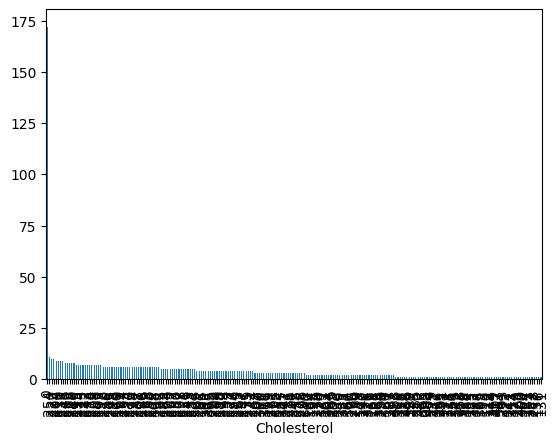

In [9]:
df["Cholesterol"].value_counts().plot(kind= "bar")

In [10]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


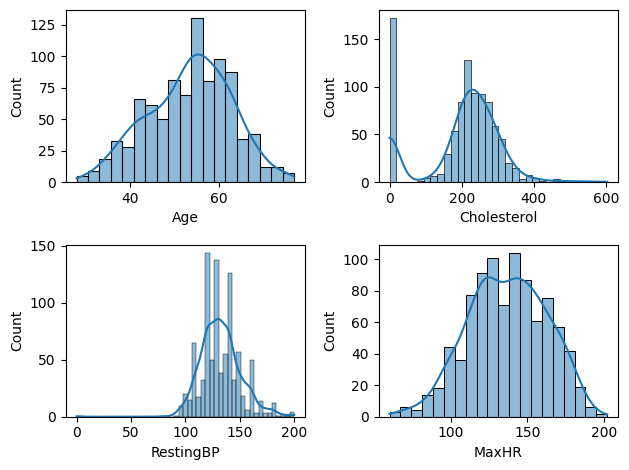

In [11]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting("Cholesterol",2)
plotting("RestingBP",3)
plotting("MaxHR",4)

plt.tight_layout()

In [12]:
ch_mean = df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()

In [13]:
ch_mean

np.float64(244.6353887399464)

In [14]:
df['Cholesterol']= df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol']= df['Cholesterol'].round(2)

In [15]:
ch_mean = df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df['RestingBP']= df['RestingBP'].replace(0,ch_mean)
df['RestingBP']= df['RestingBP'].round

In [16]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report , confusion_matrix,f1_score

In [18]:
x = df.drop("HeartDisease", axis=1)
y= df["HeartDisease"]

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train, x_test, y_train, y_test = train_test_split(
  x, y, test_size=0.33, random_state=42)

In [21]:
scaler = StandardScaler()

# Identify categorical columns (object dtype)
categorical_cols = x_train.select_dtypes(include='object').columns

# Apply one-hot encoding
x_train_encoded = pd.get_dummies(x_train, columns=categorical_cols, drop_first=True)
x_test_encoded = pd.get_dummies(x_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial to ensure test set has the same columns as the training set after encoding
# This handles cases where a category might be present in train but not test.
x_test_encoded = x_test_encoded.reindex(columns=x_train_encoded.columns, fill_value=0)

x_train_scaled = scaler.fit_transform(x_train_encoded)
x_test_scaled = scaler.transform(x_test_encoded)

In [22]:
models= {

    "logisticregression" : LogisticRegression(),
    "NB" : GaussianNB(),
    "KNN" : KNeighborsClassifier(),
    "DT" : DecisionTreeClassifier(),
    "Svm" : SVC()

}

In [23]:
result =[]

In [26]:
for name,model in models.items():
  model.fit(x_train_scaled, y_train)
  y_pred = model.predict(x_test_scaled)
  acc = accuracy_score(y_test,y_pred)
  f1 = f1_score(y_test,y_pred)
  result.append({
      'model': name,
      "accurcy": acc

  }

  )
